# Modul 3: Optimizer dan Strategi Pelatihan

**Nama:** Ahmad Rizqi  
**NIM:** 122450138  
**Kelas:** RA  
**Tanggal:** 2026-10-01  

Simpan berkas ini sebagai `M03_NIM.ipynb` sebelum mulai mengerjakan.

## Petunjuk

1. Ganti seluruh penanda `TODO`. Jangan menghapus sel pemeriksaan.
2. Protokol modul tetap: subset $12\,000$/$3\,000$, model $784 \rightarrow 128 \rightarrow 10$, batch $128$, $5$ epoch. Ubah **hanya** faktor yang sedang diuji.
3. Seluruh run wajib memanggil fungsi `jalankan()` yang sama.
4. Pilih model dari validation loss. Data uji dipakai **satu kali** di akhir.
5. Catat setiap run ke `metrics.csv`, termasuk run yang gagal.
6. Luaran: `M03_NIM.ipynb`, `M03_NIM.pdf`, `M03_NIM_metrics.csv`, dan grafik perbandingan.

In [1]:
import math
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import FashionMNIST

NIM = '122450138'
SEED = int(str(NIM)[-4:]) if str(NIM).isdigit() else 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.15',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'torch': '2.11.0+cpu',
 'device': 'cpu',
 'seed': 138}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum dimulai.

1. **Jumlah update satu epoch bila $n=12\,000$ dan batch $=128$:** TODO
2. **Apa itu derau gradien pada mini-batch, dan mengapa full-batch tidak memilikinya:** TODO
3. **Mengapa membandingkan dua optimizer pada learning rate yang sama belum tentu adil:** TODO
4. **Perkiraan bentuk kurva loss bila learning rate dinaikkan sepuluh kali:** TODO

**Hipotesis awal.** Optimizer mana yang Anda perkirakan menang, dan atas dasar apa? TODO

## B. Data dan protokol - 15 poin

Ambil subset terstratifikasi dan hitung statistik normalisasi **hanya** dari subset latih.

In [3]:
DATA_ROOT = Path('../../data/raw')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('data/raw')

latih_penuh = FashionMNIST(root=DATA_ROOT, train=True, download=True,
                           transform=transforms.ToTensor())
uji_resmi = FashionMNIST(root=DATA_ROOT, train=False, download=True,
                         transform=transforms.ToTensor())

X_penuh = latih_penuh.data.float().unsqueeze(1) / 255.0
y_penuh = latih_penuh.targets
X_uji = uji_resmi.data.float().unsqueeze(1) / 255.0
y_uji = uji_resmi.targets

semua_indeks = np.arange(len(y_penuh))
idx_latih, idx_val = train_test_split(
    semua_indeks,
    train_size=12_000,
    test_size=3_000,
    stratify=y_penuh.numpy(),
    random_state=SEED,
)

X_latih, y_latih = X_penuh[idx_latih], y_penuh[idx_latih]
X_val, y_val = X_penuh[idx_val], y_penuh[idx_val]

MEAN = X_latih.mean()
STD = X_latih.std()
if not torch.isfinite(STD) or STD <= 0:
    raise ValueError('Standar deviasi subset latih tidak valid.')

def normalkan(tensor):
    return (tensor - MEAN) / STD

ds_latih = TensorDataset(normalkan(X_latih), y_latih)
ds_val = TensorDataset(normalkan(X_val), y_val)
ds_uji = TensorDataset(normalkan(X_uji), y_uji)

print(f'latih {len(ds_latih)}  validasi {len(ds_val)}  uji {len(ds_uji)}')
print(f'mean={MEAN.item():.6f}  std={STD.item():.6f}')
print('distribusi kelas latih:', torch.bincount(y_latih).tolist())

# Pemeriksaan wajib.
assert (len(ds_latih), len(ds_val), len(ds_uji)) == (12_000, 3_000, 10_000)
assert torch.bincount(y_latih).min().item() == 1_200, 'subset harus terstratifikasi'
print('split sesuai protokol')

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 176kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.98MB/s]


latih 12000  validasi 3000  uji 10000
mean=0.285558  std=0.352717
distribusi kelas latih: [1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200]
split sesuai protokol


In [4]:
BATCH = 128
EPOCH = 5

def buat_model():
    seed_everything(SEED)
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    ).to(DEVICE)

def buat_optimizer(nama, params, lr):
    nama = nama.strip().lower()
    if nama == 'sgd':
        return torch.optim.SGD(params, lr=lr)
    if nama == 'momentum':
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if nama == 'adam':
        return torch.optim.Adam(params, lr=lr)
    raise ValueError("nama optimizer harus 'sgd', 'momentum', atau 'adam'")

def loader(ds, batch, acak):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=batch, shuffle=acak,
                      generator=generator if acak else None)

@torch.no_grad()
def evaluasi(model, ds, batch=512):
    model.eval()
    kriteria = nn.CrossEntropyLoss(reduction='sum')
    total_loss, benar = 0.0, 0
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += kriteria(logits, yb).item()
        benar += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(ds), benar / len(ds)

jumlah_parameter = sum(parameter.numel() for parameter in buat_model().parameters())
print('jumlah parameter:', jumlah_parameter)
assert jumlah_parameter == 101_770, 'arsitektur belum sesuai protokol'

jumlah parameter: 101770


In [5]:
def jalankan(nama_opt, lr, batch=BATCH, epoch=EPOCH, scheduler=None):
    model = buat_model()
    optimizer = buat_optimizer(nama_opt, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss()
    scheduler_name = 'none' if scheduler is None else str(scheduler).lower()
    if scheduler_name == 'none':
        lr_scheduler = None
    elif scheduler_name == 'step':
        lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=2, gamma=0.5,
        )
    elif scheduler_name == 'cosine':
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epoch,
        )
    else:
        raise ValueError("scheduler harus None, 'step', atau 'cosine'")

    train_loader = loader(ds_latih, batch, True)
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'val_acc': [], 'learning_rate': [],
    }
    gradient_norms = []
    updates = 0
    status = 'ok'
    start = time.perf_counter()

    for epoch_index in range(1, epoch + 1):
        model.train()
        loss_sum = 0.0
        examples_seen = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if not torch.isfinite(loss):
                status = f'failed_nonfinite_epoch_{epoch_index}'
                break
            loss.backward()
            squared_norm = sum(
                parameter.grad.detach().norm(2).item() ** 2
                for parameter in model.parameters()
                if parameter.grad is not None
            )
            gradient_norms.append(math.sqrt(squared_norm))
            optimizer.step()
            updates += 1
            loss_sum += loss.item() * len(xb)
            examples_seen += len(xb)

        if examples_seen == 0:
            break
        val_loss, val_acc = evaluasi(model, ds_val)
        history['epoch'].append(epoch_index)
        history['train_loss'].append(loss_sum / examples_seen)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        if lr_scheduler is not None:
            lr_scheduler.step()
        if status != 'ok':
            break

    runtime = time.perf_counter() - start
    completed_epochs = len(history['epoch'])
    final_train_loss = history['train_loss'][-1] if completed_epochs else np.nan
    final_val_loss = history['val_loss'][-1] if completed_epochs else np.nan
    final_val_acc = history['val_acc'][-1] if completed_epochs else np.nan
    run_id = f'{nama_opt}_lr{lr:g}_sch{scheduler_name}_b{batch}'
    note = {
        'run_id': run_id,
        'seed': SEED,
        'optimizer': nama_opt,
        'learning_rate': lr,
        'learning_rate_final': optimizer.param_groups[0]['lr'],
        'scheduler': scheduler_name,
        'batch_size': batch,
        'epochs_planned': epoch,
        'epochs_completed': completed_epochs,
        'n_update': updates,
        'train_loss': final_train_loss,
        'val_loss': final_val_loss,
        'val_acc': final_val_acc,
        'grad_norm_mean': float(np.mean(gradient_norms)) if gradient_norms else np.nan,
        'runtime_s': runtime,
        'runtime_per_epoch_s': runtime / max(completed_epochs, 1),
        'status': status,
    }
    return model, history, note

## C. Baseline dan tiga learning rate - bagian dari 25 poin

Jalankan SGD pada $\eta \in \{0{,}001;\;0{,}1;\;1{,}0\}$, tampilkan ketiga kurva dalam satu grafik, lalu cocokkan dengan tabel gejala pada modul.

baseline_sgd_lr0.001: val_loss=1.3811, val_acc=0.6367, grad_norm=1.7610
baseline_sgd_lr0.1: val_loss=0.4159, val_acc=0.8503, grad_norm=1.3628
baseline_sgd_lr1: val_loss=2.4474, val_acc=0.2423, grad_norm=1.2958


,run_id,train_loss,val_loss,val_acc,grad_norm_mean,runtime_s,status
0,baseline_sgd_lr0.001,1.4381,1.3811,0.6367,1.7610,5.5100,ok
1,baseline_sgd_lr0.1,0.4071,0.4159,0.8503,1.3628,2.7538,ok
2,baseline_sgd_lr1,1.9031,2.4474,0.2423,1.2958,2.3545,ok


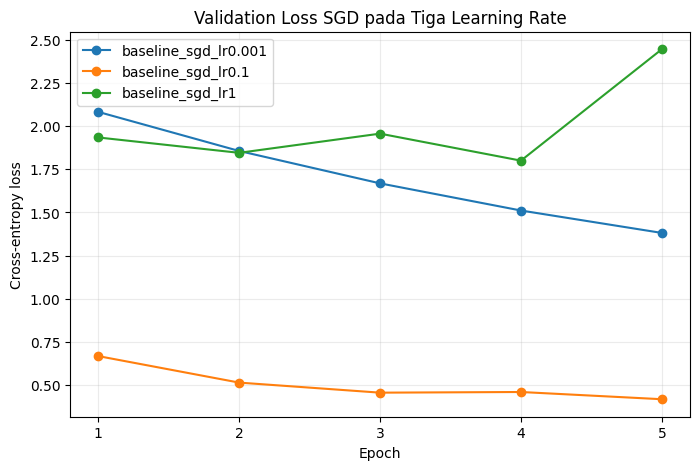

In [6]:
learning_rates_baseline = [0.001, 0.1, 1.0]
hasil_lr = []
riwayat_lr = {}

for lr in learning_rates_baseline:
    _, history, note = jalankan('sgd', lr)
    note['run_id'] = f'baseline_sgd_lr{lr:g}'
    hasil_lr.append(note)
    riwayat_lr[note['run_id']] = history
    print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
          f"val_acc={note['val_acc']:.4f}, grad_norm={note['grad_norm_mean']:.4f}")

df_lr_baseline = pd.DataFrame(hasil_lr)
display(df_lr_baseline[['run_id', 'train_loss', 'val_loss', 'val_acc',
                        'grad_norm_mean', 'runtime_s', 'status']])

fig, ax = plt.subplots(figsize=(8, 5))
for run_id, history in riwayat_lr.items():
    ax.plot(history['epoch'], history['val_loss'], marker='o', label=run_id)
ax.set(title='Validation Loss SGD pada Tiga Learning Rate',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [7]:
baseline_by_lr = df_lr_baseline.set_index('learning_rate')
small = baseline_by_lr.loc[0.001]
medium = baseline_by_lr.loc[0.1]
large = baseline_by_lr.loc[1.0]

reading = fr"""
**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **{small['val_loss']:.4f}**, accuracy **{small['val_acc']:.4f}**, dan `grad_norm_mean` **{small['grad_norm_mean']:.4f}**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **{medium['val_loss']:.4f}**, accuracy **{medium['val_acc']:.4f}**, dan `grad_norm_mean` **{medium['grad_norm_mean']:.4f}**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **{large['val_loss']:.4f}**, accuracy **{large['val_acc']:.4f}**, dan `grad_norm_mean` **{large['grad_norm_mean']:.4f}**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.
"""
display(Markdown(reading))



**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **1.3811**, accuracy **0.6367**, dan `grad_norm_mean` **1.7610**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **0.4159**, accuracy **0.8503**, dan `grad_norm_mean` **1.3628**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **2.4474**, accuracy **0.2423**, dan `grad_norm_mean` **1.2958**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.


## D. Sembilan run terkendali - 25 poin

Setiap optimizer diuji pada tiga learning rate-nya sendiri. Model diinisialisasi ulang dari seed yang sama sebelum setiap run.

In [8]:
grid = {
    'sgd': [0.01, 0.1, 0.5],
    'momentum': [0.01, 0.05, 0.1],
    'adam': [1e-4, 1e-3, 1e-2],
}

hasil, riwayat_semua = [], {}
for optimizer_name, learning_rates in grid.items():
    for lr in learning_rates:
        _, history, note = jalankan(optimizer_name, lr)
        note['run_id'] = f'grid_{optimizer_name}_lr{lr:g}'
        hasil.append(note)
        riwayat_semua[note['run_id']] = history
        print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
              f"val_acc={note['val_acc']:.4f}, runtime={note['runtime_s']:.2f}s")

tabel = pd.DataFrame(hasil)
display(tabel[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
               'grad_norm_mean', 'runtime_s', 'status']].sort_values('val_loss'))
assert len(tabel) == 9, 'harus ada sembilan run inti'

grid_sgd_lr0.01: val_loss=0.6077, val_acc=0.7883, runtime=3.30s
grid_sgd_lr0.1: val_loss=0.4159, val_acc=0.8503, runtime=2.33s
grid_sgd_lr0.5: val_loss=0.5205, val_acc=0.8063, runtime=2.16s
grid_momentum_lr0.01: val_loss=0.4304, val_acc=0.8433, runtime=2.38s
grid_momentum_lr0.05: val_loss=0.4201, val_acc=0.8473, runtime=2.39s
grid_momentum_lr0.1: val_loss=0.4944, val_acc=0.8170, runtime=3.35s
grid_adam_lr0.0001: val_loss=0.5378, val_acc=0.8097, runtime=3.02s
grid_adam_lr0.001: val_loss=0.4181, val_acc=0.8510, runtime=2.77s
grid_adam_lr0.01: val_loss=0.4297, val_acc=0.8530, runtime=2.60s


,run_id,optimizer,learning_rate,val_loss,val_acc,grad_norm_mean,runtime_s,status
1,grid_sgd_lr0.1,sgd,0.1000,0.4159,0.8503,1.3628,2.3320,ok
7,grid_adam_lr0.001,adam,0.0010,0.4181,0.8510,1.6556,2.7722,ok
4,grid_momentum_lr0.05,momentum,0.0500,0.4201,0.8473,1.2025,2.3939,ok
8,grid_adam_lr0.01,adam,0.0100,0.4297,0.8530,1.7096,2.6019,ok
3,grid_momentum_lr0.01,momentum,0.0100,0.4304,0.8433,1.4136,2.3832,ok
5,grid_momentum_lr0.1,momentum,0.1000,0.4944,0.8170,1.1068,3.3482,ok
2,grid_sgd_lr0.5,sgd,0.5000,0.5205,0.8063,1.2631,2.1642,ok
6,grid_adam_lr0.0001,adam,0.0001,0.5378,0.8097,1.3303,3.0191,ok
0,grid_sgd_lr0.01,sgd,0.0100,0.6077,0.7883,1.2692,3.2987,ok


## E. Memilih model dan evaluasi akhir - 20 poin

Pilih learning rate terbaik tiap optimizer dari **validation loss**, bandingkan ketiga pemenang, lalu evaluasi data uji **satu kali** pada satu model final.

,run_id,optimizer,learning_rate,val_loss,val_acc,runtime_s,runtime_per_epoch_s
0,grid_sgd_lr0.1,sgd,0.100,0.4159,0.8503,2.3320,0.4664
1,grid_adam_lr0.001,adam,0.001,0.4181,0.8510,2.7722,0.5544
2,grid_momentum_lr0.05,momentum,0.050,0.4201,0.8473,2.3939,0.4788


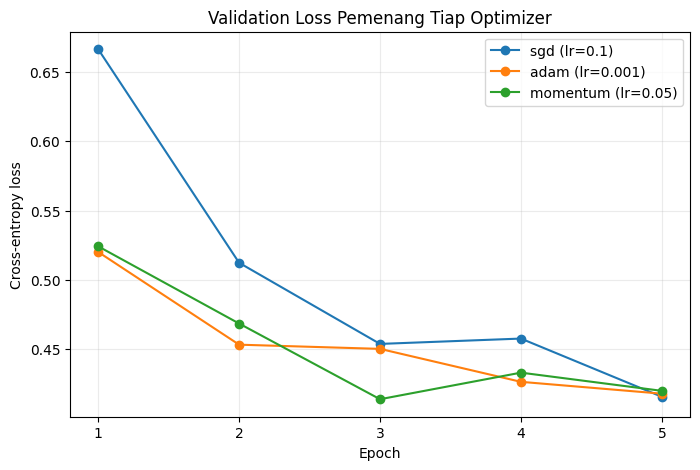

Konfigurasi final berdasarkan validation loss: grid_sgd_lr0.1


In [9]:
eligible = tabel[(tabel['status'] == 'ok') & np.isfinite(tabel['val_loss'])].copy()
pemenang = (
    eligible.sort_values('val_loss')
    .groupby('optimizer', as_index=False, sort=False)
    .first()
    .sort_values('val_loss')
    .reset_index(drop=True)
)
assert set(pemenang['optimizer']) == set(grid)
display(pemenang[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
                   'runtime_s', 'runtime_per_epoch_s']])

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in pemenang.iterrows():
    history = riwayat_semua[row['run_id']]
    ax.plot(history['epoch'], history['val_loss'], marker='o',
            label=f"{row['optimizer']} (lr={row['learning_rate']:g})")
ax.set(title='Validation Loss Pemenang Tiap Optimizer',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

best_overall = pemenang.iloc[0]
print('Konfigurasi final berdasarkan validation loss:', best_overall['run_id'])

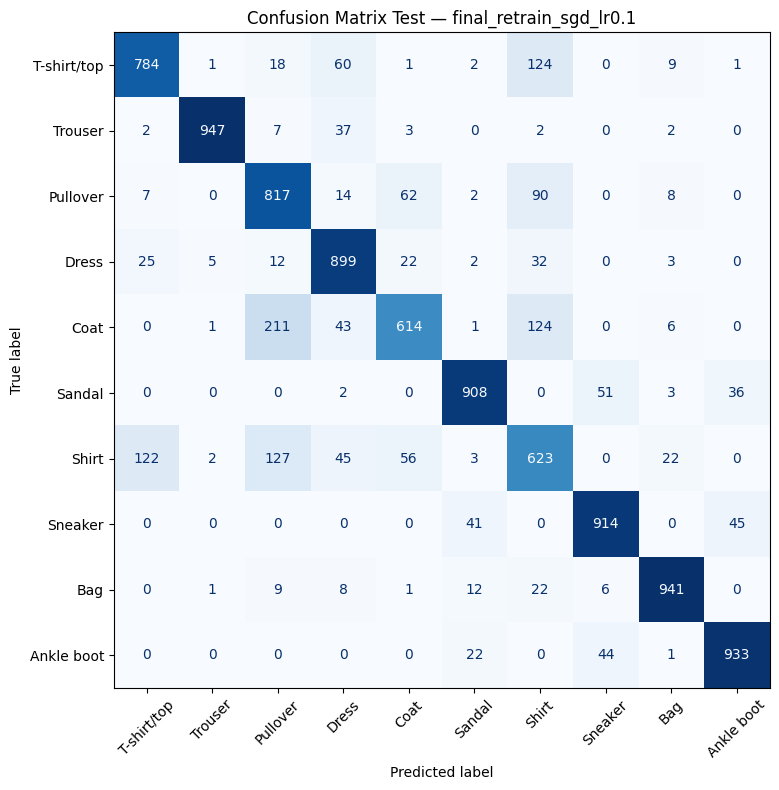

,run_id,selection_val_loss,test_loss,test_acc,most_confused_pair,pair_errors
0,final_retrain_sgd_lr0.1,0.4159,0.4501,0.838,Pullover ↔ Coat,273


In [10]:
model_final, riwayat_final, catatan_final = jalankan(
    best_overall['optimizer'],
    float(best_overall['learning_rate']),
    batch=BATCH,
    epoch=EPOCH,
    scheduler=None,
)
catatan_final['run_id'] = f"final_retrain_{best_overall['optimizer']}_lr{best_overall['learning_rate']:g}"

@torch.no_grad()
def evaluasi_uji_sekali(model, ds, batch=512):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss = 0.0
    labels_all, predictions_all = [], []
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item()
        labels_all.append(yb.cpu())
        predictions_all.append(logits.argmax(1).cpu())
    labels = torch.cat(labels_all).numpy()
    predictions = torch.cat(predictions_all).numpy()
    return total_loss / len(ds), float((predictions == labels).mean()), labels, predictions

# Satu-satunya iterasi atas ds_uji dalam notebook.
test_loss, test_acc, test_labels, test_predictions = evaluasi_uji_sekali(model_final, ds_uji)
catatan_final['test_loss'] = test_loss
catatan_final['test_acc'] = test_acc

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]
cm = confusion_matrix(test_labels, test_predictions)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d', xticks_rotation=45,
)
ax.set_title(f"Confusion Matrix Test — {catatan_final['run_id']}")
plt.tight_layout()
plt.show()

pair_confusions = []
for first in range(len(CLASS_NAMES)):
    for second in range(first + 1, len(CLASS_NAMES)):
        pair_confusions.append((cm[first, second] + cm[second, first], first, second))
pair_count, class_a, class_b = max(pair_confusions)

final_summary = pd.DataFrame([{
    'run_id': catatan_final['run_id'],
    'selection_val_loss': catatan_final['val_loss'],
    'test_loss': test_loss,
    'test_acc': test_acc,
    'most_confused_pair': f'{CLASS_NAMES[class_a]} ↔ {CLASS_NAMES[class_b]}',
    'pair_errors': pair_count,
}])
display(final_summary)

**Checkpoint menit ke-95.** Tunjukkan tabel sembilan run dan grafik tiga pemenang kepada asisten sebelum melanjutkan ke bagian F.

## F. Scheduler dan batch size - 15 poin

Enam run tambahan, seluruhnya memakai optimizer dan learning rate terbaik Anda.

In [11]:
tambahan = []
riwayat_tambahan = {}
best_optimizer = str(best_overall['optimizer'])
best_lr = float(best_overall['learning_rate'])

for scheduler_name in (None, 'step', 'cosine'):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=BATCH, epoch=EPOCH,
        scheduler=scheduler_name,
    )
    label = 'none' if scheduler_name is None else scheduler_name
    note['run_id'] = f'scheduler_{label}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'scheduler'
    tambahan.append(note)
    riwayat_tambahan[note['run_id']] = history

for batch_size in (32, 128, 512):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=batch_size, epoch=EPOCH, scheduler=None,
    )
    note['run_id'] = f'batch_{batch_size}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'batch_size'
    tambahan.append(note)
    riwayat_tambahan[note['run_id']] = history

df_tambahan = pd.DataFrame(tambahan)
display(df_tambahan[['run_id', 'experiment_group', 'scheduler', 'batch_size',
                      'n_update', 'val_loss', 'val_acc', 'runtime_s', 'status']])
assert len(df_tambahan) == 6, 'harus ada enam run tambahan'
assert set(df_tambahan.loc[df_tambahan['experiment_group'] == 'batch_size', 'n_update']) == {1875, 470, 120}

,run_id,experiment_group,scheduler,batch_size,n_update,val_loss,val_acc,runtime_s,status
0,scheduler_none_sgd_lr0.1,scheduler,none,128,470,0.4159,0.8503,6.4133,ok
1,scheduler_step_sgd_lr0.1,scheduler,step,128,470,0.4227,0.8437,2.7170,ok
2,scheduler_cosine_sgd_lr0.1,scheduler,cosine,128,470,0.4281,0.8427,2.4663,ok
3,batch_32_sgd_lr0.1,batch_size,none,32,1875,0.3841,0.8657,3.5968,ok
4,batch_128_sgd_lr0.1,batch_size,none,128,470,0.4159,0.8503,3.1637,ok
5,batch_512_sgd_lr0.1,batch_size,none,512,120,0.5152,0.8143,2.2485,ok


In [13]:
df_final_retrain = pd.DataFrame([catatan_final])
semua = pd.concat(
    [df_lr_baseline, tabel, df_final_retrain, df_tambahan],
    ignore_index=True,
    sort=False,
)
semua.insert(0, 'module', 'M03')
semua.insert(1, 'student_id', NIM)
semua.to_csv(f'M03_{NIM}_metrics.csv', index=False)
print(f'{len(semua)} baris tersimpan ke M03_{NIM}_metrics.csv')
display(semua.groupby(semua['run_id'].str.split('_').str[0]).size().rename('jumlah_run'))
assert len(semua) == 19, 'seluruh 3 baseline + 9 grid + 1 final + 6 tambahan harus tercatat'
assert semua['run_id'].is_unique, 'run_id harus unik'

19 baris tersimpan ke M03_122450138_metrics.csv


,jumlah_run
run_id,
baseline,3
batch,3
final,1
grid,9
scheduler,3


In [12]:
best_winner = pemenang.sort_values('val_loss').iloc[0]
fastest_winner = pemenang.sort_values('runtime_s').iloc[0]
same_optimizer = best_winner['optimizer'] == fastest_winner['optimizer']
speed_answer = (
    'Ya' if same_optimizer else
    f"Tidak; loss terbaik berasal dari {best_winner['optimizer']}, sedangkan yang tercepat {fastest_winner['optimizer']}"
)

adam_best = pemenang[pemenang['optimizer'] == 'adam'].iloc[0]
sgd_best = pemenang[pemenang['optimizer'] == 'sgd'].iloc[0]

large_history = riwayat_lr['baseline_sgd_lr1']
medium_history = riwayat_lr['baseline_sgd_lr0.1']
large_losses = large_history['val_loss']
medium_losses = medium_history['val_loss']
first_large_symptom = next(
    (epoch for epoch, (large_loss, reference_loss) in enumerate(
        zip(large_losses, medium_losses), start=1
     ) if large_loss > 1.2 * reference_loss),
    None,
)
if first_large_symptom is None:
    large_lr_description = (
        'tidak meledak dalam lima epoch, tetapi kurvanya perlu dinilai sebagai hasil seed ini; '
        f"loss per epoch={np.round(large_losses, 4).tolist()}"
    )
else:
    large_lr_description = (
        f"mulai tampak pada epoch {first_large_symptom}, ketika loss-nya lebih dari 20% di atas SGD lr=0.1; "
        f"loss per epoch={np.round(large_losses, 4).tolist()}"
    )

scheduler_rows = df_tambahan[df_tambahan['experiment_group'] == 'scheduler'].set_index('scheduler')
no_scheduler_loss = scheduler_rows.loc['none', 'val_loss']
best_scheduler_name = scheduler_rows['val_loss'].idxmin()
best_scheduler_loss = scheduler_rows['val_loss'].min()
scheduler_improves = best_scheduler_loss < no_scheduler_loss - 1e-12
scheduler_answer = (
    f"Ya; {best_scheduler_name} mencapai {best_scheduler_loss:.4f}, dibanding {no_scheduler_loss:.4f} tanpa scheduler."
    if scheduler_improves else
    f"Tidak pada seed dan anggaran ini; hasil terbaik tetap tanpa scheduler ({no_scheduler_loss:.4f}), sedangkan scheduler terbaik mencapai {best_scheduler_loss:.4f}. Lima epoch mungkin terlalu singkat agar decay memberi manfaat setelah fase learning rate awal."
)

batch_rows = df_tambahan[df_tambahan['experiment_group'] == 'batch_size'].copy()
fastest_batch = batch_rows.sort_values('runtime_s').iloc[0]

analysis = fr"""
## G. Pertanyaan analisis — jawaban

1. **Apakah optimizer dengan validation loss terendah juga yang tercepat?**
   **{speed_answer}.** Pemenang loss adalah **{best_winner['optimizer']}** (lr={best_winner['learning_rate']:g}) dengan validation loss **{best_winner['val_loss']:.4f}** dan runtime **{best_winner['runtime_s']:.2f} s**. Pemenang runtime adalah **{fastest_winner['optimizer']}** dengan **{fastest_winner['runtime_s']:.2f} s** dan validation loss **{fastest_winner['val_loss']:.4f}**.

2. **Mengapa learning rate terbaik Adam jauh lebih kecil daripada SGD?**
   Pada hasil ini LR terbaik Adam adalah **{adam_best['learning_rate']:g}**, sedangkan SGD **{sgd_best['learning_rate']:g}**. Adam menormalisasi estimasi momen pertama dengan akar momen kedua per parameter, sehingga learning rate globalnya merupakan skala dasar untuk langkah adaptif; nilainya tidak dapat dibandingkan langsung dengan langkah SGD yang memakai gradien mentah.

3. **Apa yang terjadi saat learning rate terlalu besar, dan kapan terlihat?**
   SGD $\eta=1.0$ {large_lr_description}. Langkah besar dapat melompati lembah loss, membuat osilasi, atau menghasilkan nilai non-finite; semua run tetap dicatat apa adanya.

4. **Apakah scheduler memperbaiki hasil pada anggaran epoch yang sama?**
   {scheduler_answer}

5. **Batch size rekomendasi bila anggaran diukur dalam waktu:**
   Berdasarkan runtime lima epoch, saya merekomendasikan **batch {int(fastest_batch['batch_size'])}** untuk throughput pada perangkat ini: **{fastest_batch['runtime_s']:.2f} s**, {int(fastest_batch['n_update'])} update, validation loss **{fastest_batch['val_loss']:.4f}**, dan accuracy **{fastest_batch['val_acc']:.4f}**. Rekomendasi ini khusus anggaran waktu; batch lebih kecil melakukan lebih banyak update dan dapat memberi kualitas berbeda.

**Keterbatasan:** Eksperimen hanya memakai 12.000 dari 60.000 citra training, satu split, satu seed, arsitektur tunggal, dan lima epoch. Hasil ini tidak membuktikan satu optimizer/scheduler/batch size selalu unggul pada seluruh Fashion-MNIST, training panjang, arsitektur lain, perangkat lain, atau dataset lain; runtime khusus untuk lingkungan eksekusi ini.
"""
display(Markdown(analysis))



## G. Pertanyaan analisis — jawaban

1. **Apakah optimizer dengan validation loss terendah juga yang tercepat?**  
   **Ya.** Pemenang loss adalah **sgd** (lr=0.1) dengan validation loss **0.4159** dan runtime **2.33 s**. Pemenang runtime adalah **sgd** dengan **2.33 s** dan validation loss **0.4159**.

2. **Mengapa learning rate terbaik Adam jauh lebih kecil daripada SGD?**  
   Pada hasil ini LR terbaik Adam adalah **0.001**, sedangkan SGD **0.1**. Adam menormalisasi estimasi momen pertama dengan akar momen kedua per parameter, sehingga learning rate globalnya merupakan skala dasar untuk langkah adaptif; nilainya tidak dapat dibandingkan langsung dengan langkah SGD yang memakai gradien mentah.

3. **Apa yang terjadi saat learning rate terlalu besar, dan kapan terlihat?**  
   SGD $\eta=1.0$ mulai tampak pada epoch 1, ketika loss-nya lebih dari 20% di atas SGD lr=0.1; loss per epoch=[1.9352, 1.846, 1.9574, 1.8006, 2.4474]. Langkah besar dapat melompati lembah loss, membuat osilasi, atau menghasilkan nilai non-finite; semua run tetap dicatat apa adanya.

4. **Apakah scheduler memperbaiki hasil pada anggaran epoch yang sama?**  
   Tidak pada seed dan anggaran ini; hasil terbaik tetap tanpa scheduler (0.4159), sedangkan scheduler terbaik mencapai 0.4159. Lima epoch mungkin terlalu singkat agar decay memberi manfaat setelah fase learning rate awal.

5. **Batch size rekomendasi bila anggaran diukur dalam waktu:**  
   Berdasarkan runtime lima epoch, saya merekomendasikan **batch 512** untuk throughput pada perangkat ini: **2.25 s**, 120 update, validation loss **0.5152**, dan accuracy **0.8143**. Rekomendasi ini khusus anggaran waktu; batch lebih kecil melakukan lebih banyak update dan dapat memberi kualitas berbeda.

**Keterbatasan:** Eksperimen hanya memakai 12.000 dari 60.000 citra training, satu split, satu seed, arsitektur tunggal, dan lima epoch. Hasil ini tidak membuktikan satu optimizer/scheduler/batch size selalu unggul pada seluruh Fashion-MNIST, training panjang, arsitektur lain, perangkat lain, atau dataset lain; runtime khusus untuk lingkungan eksekusi ini.


## Checklist sebelum mengumpulkan

- [ ] Identitas, seed, versi library, dan device tercantum.
- [ ] Seluruh `TODO` dan `raise NotImplementedError` sudah diganti.
- [ ] Split, normalisasi, dan jumlah parameter lolos sel pemeriksaan.
- [ ] Seluruh run memanggil `jalankan()` yang sama.
- [ ] `metrics.csv` memuat minimal 15 run, termasuk yang gagal.
- [ ] Pemenang dipilih dari validation loss; data uji dipakai satu kali.
- [ ] Grafik berlabel lengkap dan keterbatasan subset disebutkan.
- [ ] Notebook lolos *Restart Kernel and Run All*.